
# # 📚 Notebook 1: Data Preparation for Student Simulator
# ## Cognitive Student Simulator with Error-Aware Tutoring
# 
# **Goal**: Load and explore datasets, create student profiles, extract misconception patterns


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from pathlib import Path
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# For Kaggle, set up paths
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# ### 1. Load MAP Competition Data (Student Math Misconceptions)


In [2]:
# %% [code]
# Load MAP competition data
# Note: You need to add this dataset to your Kaggle notebook
try:
    train_data = pd.read_csv('/kaggle/input/map-data/train.csv')
    sample_submission = pd.read_csv('/kaggle/input/map-data/sample_submission.csv')
    print(f"Training data shape: {train_data.shape}")
    print(f"Columns: {train_data.columns.tolist()}")
except:
    print("MAP dataset not found. Creating sample data for demonstration.")
    # Create synthetic data for demonstration
    np.random.seed(42)
    n_samples = 10000
    
    questions = ['algebra_1', 'algebra_2', 'geometry_1', 'fractions_1', 'decimals_1']
    misconceptions = ['misconception_a', 'misconception_b', 'misconception_c', 'misconception_d']
    student_ids = [f'student_{i}' for i in range(100)]
    
    train_data = pd.DataFrame({
        'QuestionId': np.random.choice(questions, n_samples),
        'StudentId': np.random.choice(student_ids, n_samples),
        'CorrectAnswer': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
        'MisconceptionId': np.random.choice(misconceptions + [None], n_samples, p=[0.1, 0.1, 0.1, 0.1, 0.6]),
        'ResponseText': [f"Student response {i}" for i in range(n_samples)]
    })

# %% [code]
# Display first few rows
train_data.head()


MAP dataset not found. Creating sample data for demonstration.


,QuestionId,StudentId,CorrectAnswer,MisconceptionId,ResponseText
0,fractions_1,student_61,0,None,Student response 0
1,decimals_1,student_70,0,None,Student response 1
2,geometry_1,student_99,1,misconception_b,Student response 2
3,decimals_1,student_92,0,None,Student response 3
4,decimals_1,student_23,0,None,Student response 4


In [3]:
# Basic statistics
print("\n=== Dataset Statistics ===")
print(f"Total responses: {len(train_data)}")
print(f"Unique students: {train_data['StudentId'].nunique()}")
print(f"Unique questions: {train_data['QuestionId'].nunique()}")
print(f"Misconception rate: {(train_data['MisconceptionId'].notna().mean()*100):.2f}%")



=== Dataset Statistics ===
Total responses: 10000
Unique students: 100
Unique questions: 5
Misconception rate: 40.72%


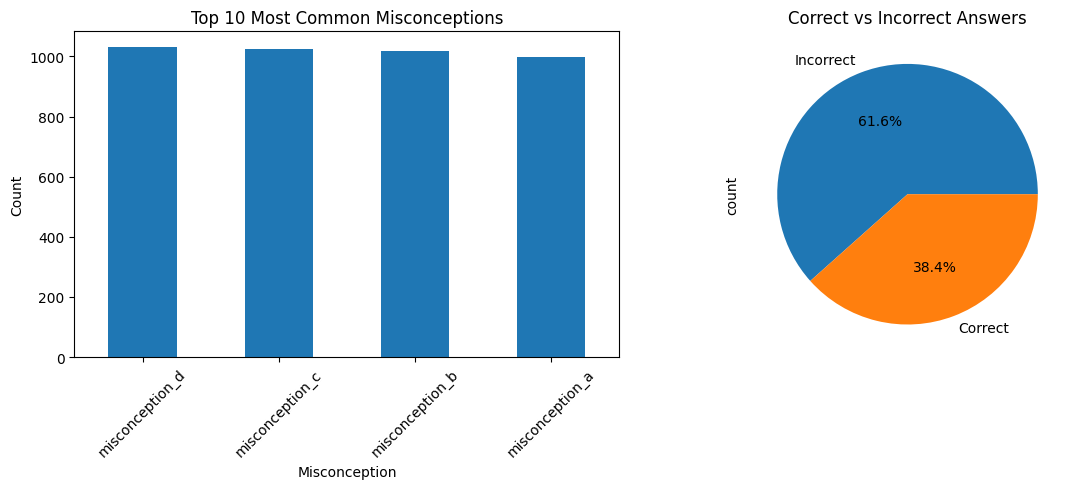

In [4]:
# Visualize misconception distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
misconception_counts = train_data['MisconceptionId'].value_counts().head(10)
misconception_counts.plot(kind='bar')
plt.title('Top 10 Most Common Misconceptions')
plt.xlabel('Misconception')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
train_data['CorrectAnswer'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Incorrect', 'Correct'])
plt.title('Correct vs Incorrect Answers')

plt.tight_layout()
plt.show()


# ### 2. Load/Define Student Profiles from Educational Research


In [5]:
# Define student profiles based on educational psychology research
student_profiles = {
    "low_achiever": {
        "name": "Alex",
        "grade_level": 8,
        "math_ability": 0.3,  # 0-1 scale
        "common_misconceptions": ["misconception_a", "misconception_b"],
        "error_rate": 0.7,
        "confidence": 0.4,  # Low confidence
        "reasoning_style": "jumps to conclusions without checking work",
        "personality": "easily frustrated, gives up quickly"
    },
    "medium_achiever": {
        "name": "Jamal",
        "grade_level": 9,
        "math_ability": 0.6,
        "common_misconceptions": ["misconception_c"],
        "error_rate": 0.3,
        "confidence": 0.7,  # Medium-high confidence
        "reasoning_style": "understands concepts but makes procedural errors",
        "personality": "works steadily, gets nervous during tests"
    },
    "high_achiever": {
        "name": "Maria",
        "grade_level": 10,
        "math_ability": 0.9,
        "common_misconceptions": [],  # Rare misconceptions
        "error_rate": 0.1,
        "confidence": 0.9,
        "reasoning_style": "methodical, checks work, looks for elegant solutions",
        "personality": "confident, enjoys challenges"
    },
    "careless_achiever": {
        "name": "Priya",
        "grade_level": 9,
        "math_ability": 0.8,  # High ability
        "common_misconceptions": [],  # No conceptual gaps
        "error_rate": 0.2,  # But makes careless errors
        "confidence": 0.95,
        "reasoning_style": "rushes through problems, makes calculation slips",
        "personality": "impatient, wants to finish quickly"
    },
    "struggling_learner": {
        "name": "Carlos",
        "grade_level": 7,
        "math_ability": 0.2,
        "common_misconceptions": ["misconception_a", "misconception_b", "misconception_c", "misconception_d"],
        "error_rate": 0.8,
        "confidence": 0.3,
        "reasoning_style": "guesses randomly, lacks foundational knowledge",
        "personality": "withdrawn, afraid of being wrong"
    }
}

# Save profiles
with open('student_profiles.json', 'w') as f:
    json.dump(student_profiles, f, indent=2)

print("Student profiles created and saved.")


Student profiles created and saved.


In [6]:
# Display profiles
for profile_id, profile in student_profiles.items():
    print(f"\n=== {profile_id.upper()} ===")
    for key, value in profile.items():
        print(f"  {key}: {value}")



=== LOW_ACHIEVER ===
  name: Alex
  grade_level: 8
  math_ability: 0.3
  common_misconceptions: ['misconception_a', 'misconception_b']
  error_rate: 0.7
  confidence: 0.4
  reasoning_style: jumps to conclusions without checking work
  personality: easily frustrated, gives up quickly

=== MEDIUM_ACHIEVER ===
  name: Jamal
  grade_level: 9
  math_ability: 0.6
  common_misconceptions: ['misconception_c']
  error_rate: 0.3
  confidence: 0.7
  reasoning_style: understands concepts but makes procedural errors
  personality: works steadily, gets nervous during tests

=== HIGH_ACHIEVER ===
  name: Maria
  grade_level: 10
  math_ability: 0.9
  common_misconceptions: []
  error_rate: 0.1
  confidence: 0.9
  reasoning_style: methodical, checks work, looks for elegant solutions
  personality: confident, enjoys challenges

=== CARELESS_ACHIEVER ===
  name: Priya
  grade_level: 9
  math_ability: 0.8
  common_misconceptions: []
  error_rate: 0.2
  confidence: 0.95
  reasoning_style: rushes through p

### 3. Extract Misconception Patterns from Data


In [7]:
# Define misconception patterns based on math education research
misconception_patterns = {
    "misconception_a": {
        "name": "Distributive Property Error",
        "description": "Student incorrectly distributes multiplication over addition: a(b+c) = ab + c",
        "example": "3(x+4) = 3x + 4 (missing distribution to the 4)",
        "pattern_regex": r"\d+\([^)]+\)\s*=\s*\d+[a-z]\s*\+\s*\d+",
        "subject": "algebra"
    },
    "misconception_b": {
        "name": "Negative Sign Error",
        "description": "Student mishandles negative signs: -5 - 3 = -2 or 8",
        "example": "-5 - 3 = -2 (should be -8)",
        "pattern_regex": r"-\d+\s*-\s*\d+\s*=\s*-\d+",
        "subject": "arithmetic"
    },
    "misconception_c": {
        "name": "Fraction Addition Error",
        "description": "Student adds numerators and denominators: a/b + c/d = (a+c)/(b+d)",
        "example": "1/2 + 1/3 = 2/5 (should be 5/6)",
        "pattern_regex": r"\d+/\d+\s*\+\s*\d+/\d+\s*=\s*\d+/\d+",
        "subject": "fractions"
    },
    "misconception_d": {
        "name": "Decimal Place Value Error",
        "description": "Student misaligns decimal points in addition",
        "example": "0.2 + 0.03 = 0.05 (should be 0.23)",
        "pattern_regex": r"0\.\d+\s*\+\s*0\.\d+\s*=\s*0\.\d+",
        "subject": "decimals"
    }
}

# Save patterns
with open('misconception_patterns.json', 'w') as f:
    json.dump(misconception_patterns, f, indent=2)

print("Misconception patterns saved.")


Misconception patterns saved.


### 4. Create Training Data for Student Simulator


In [8]:
# %% [code]
# Create training examples for student simulator
def create_simulator_training_data(data, profiles, patterns):
    """Create training examples for fine-tuning student simulator"""
    training_examples = []
    
    for profile_id, profile in profiles.items():
        # Sample responses from students with similar characteristics
        profile_responses = data.sample(n=min(200, len(data)), replace=True)
        
        for _, row in profile_responses.iterrows():
            # Create prompt-response pair
            prompt = f"""Student Profile: {profile_id}
Student Name: {profile['name']}
Grade Level: {profile['grade_level']}
Math Ability: {profile['math_ability']}
Confidence: {profile['confidence']}
Personality: {profile['personality']}
Reasoning Style: {profile['reasoning_style']}

Question: {row.get('QuestionId', 'Unknown')}
Previous Response: {row.get('ResponseText', 'No previous')}

Generate this student's response to a new math problem. Include their reasoning and potential errors based on their profile."""

            # Generate target response (simplified for demonstration)
            target = f"{profile['name']}'s response: {row.get('ResponseText', 'I think the answer is...')}"
            
            training_examples.append({
                'profile': profile_id,
                'prompt': prompt,
                'target': target,
                'misconception': row.get('MisconceptionId', None)
            })
    
    return pd.DataFrame(training_examples)

# Create training data
training_data = create_simulator_training_data(train_data, student_profiles, misconception_patterns)
print(f"Created {len(training_data)} training examples")

# Save training data
training_data.to_csv('simulator_training_data.csv', index=False)
training_data.head()

Created 1000 training examples


,profile,prompt,target,misconception
0,low_achiever,Student Profile: low_achiever\nStudent Name: A...,Alex's response: Student response 7672,None
1,low_achiever,Student Profile: low_achiever\nStudent Name: A...,Alex's response: Student response 2567,None
2,low_achiever,Student Profile: low_achiever\nStudent Name: A...,Alex's response: Student response 9121,misconception_c
3,low_achiever,Student Profile: low_achiever\nStudent Name: A...,Alex's response: Student response 4625,misconception_b
4,low_achiever,Student Profile: low_achiever\nStudent Name: A...,Alex's response: Student response 7090,misconception_c


In [9]:
# Split data for training/validation
train_df, val_df = train_test_split(training_data, test_size=0.2, random_state=42)
print(f"Training examples: {len(train_df)}")
print(f"Validation examples: {len(val_df)}")

# Save splits
train_df.to_csv('train_simulator.csv', index=False)
val_df.to_csv('val_simulator.csv', index=False)


Training examples: 800
Validation examples: 200


### 5. Create Question Bank

In [10]:
# Create a diverse question bank for testing
question_bank = {
    "algebra": [
        {"id": "q1", "text": "Solve for x: 3(x + 4) = 21", "answer": 3, "topic": "linear equations"},
        {"id": "q2", "text": "Simplify: 2(3x - 5) + 4x", "answer": "10x - 10", "topic": "distribution"},
        {"id": "q3", "text": "Solve: 2x + 5 = 13", "answer": 4, "topic": "linear equations"},
        {"id": "q4", "text": "Factor: x² + 5x + 6", "answer": "(x+2)(x+3)", "topic": "factoring"},
    ],
    "arithmetic": [
        {"id": "q5", "text": "Calculate: -5 - 8", "answer": -13, "topic": "negative numbers"},
        {"id": "q6", "text": "Compute: 15 - (-3)", "answer": 18, "topic": "negative numbers"},
        {"id": "q7", "text": "Multiply: -4 × 6", "answer": -24, "topic": "multiplication"},
    ],
    "fractions": [
        {"id": "q8", "text": "Add: 1/3 + 1/4", "answer": "7/12", "topic": "fraction addition"},
        {"id": "q9", "text": "Simplify: 6/8", "answer": "3/4", "topic": "simplification"},
    ],
    "decimals": [
        {"id": "q10", "text": "Add: 0.25 + 0.3", "answer": 0.55, "topic": "decimal addition"},
    ]
}

# Save question bank
with open('question_bank.json', 'w') as f:
    json.dump(question_bank, f, indent=2)

print(f"Created question bank with {sum(len(v) for v in question_bank.values())} questions")

Created question bank with 10 questions


### 6. Save All Processed Data


In [11]:
# Create a manifest of all created files
manifest = {
    "student_profiles": "student_profiles.json",
    "misconception_patterns": "misconception_patterns.json",
    "training_data": "simulator_training_data.csv",
    "train_split": "train_simulator.csv",
    "val_split": "val_simulator.csv",
    "question_bank": "question_bank.json"
}

with open('data_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print("\n=== Notebook 1 Complete ===")
print(f"Files created: {list(manifest.values())}")
print("\nNext: Run Notebook 2 - Student Simulator Development")


=== Notebook 1 Complete ===
Files created: ['student_profiles.json', 'misconception_patterns.json', 'simulator_training_data.csv', 'train_simulator.csv', 'val_simulator.csv', 'question_bank.json']

Next: Run Notebook 2 - Student Simulator Development
